In [42]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path

from measurements import get_prev_or_next_frame, get_mesh_from_bm_image
# from sklearn import preprocessing, model_selection, feature_selection, metrics, inspection, pipeline
from skimage import io
import pyvista as pv

import ipyvolume as ipv

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles'
all_df = pd.read_pickle(path.join(dataset_dir,f'all_df.pkl'))
basals = pd.read_pickle(path.join(dataset_dir,f'basals.pkl'))
divisions = pd.read_pickle(path.join(dataset_dir,f'divisions.pkl'))
births = pd.read_pickle(path.join(dataset_dir,f'births.pkl'))

In [71]:
# Isolate division frame

delam = basals[basals['Delaminate next frame','Meta']]

# Get cells with at least 3 frames prior to delamination
delam_aligned_cells = []
for idx,c in delam.iterrows():
    frame,trackID = idx
    if frame > 2:

        this_cell = basals.reset_index().set_index('TrackID').loc[trackID]
        if len(this_cell['Frame']) > 3:
            delam_aligned_cells.append(this_cell.sort_values('Frame').iloc[-4:-1])


In [93]:
delam_stats = []
for cell in delam_aligned_cells:
    
    speeds = np.diff(cell.iloc[-3:-1]['Height to BM','Measurement tissue geometry'])
    curvature = cell['Mean curvature 10um','Measurement tissue geometry']
    
    c = {'TrackID':cell.index[0],'Region':cell['Region'][0],
        'Mean speed':np.nanmean(speeds),'Max speed':np.nanmax(speeds),
         'Basal area': cell.iloc[-1]['Basal area','Measurement cell shape'],
        'Basal area rate': np.nanmean(np.diff(cell.iloc[-4:-1]['Basal area','Measurement cell shape'])),
        'Mean curvature':np.nanmean(curvature),
        'Final curvature':curvature.iloc[-1],'Initial curvature':curvature.iloc[0],
        }
    delam_stats.append(c)

delam_stats = pd.DataFrame(delam_stats)
delam_stats


,TrackID,Region,Mean speed,Max speed,Basal area,Basal area rate,Mean curvature,Final curvature,Initial curvature
0,R1_27,R1,-1.140152,-1.140152,14.1875,-8.8750,-0.103385,-0.167120,-0.116637
1,R1_93,R1,0.151334,0.151334,19.6875,-1.6875,-0.534624,-1.013404,-0.278622
2,R1_291,R1,0.624076,0.624076,21.3750,-7.1250,0.090229,0.098155,0.126807
3,R1_311,R1,1.187933,1.187933,24.1875,-4.2500,0.229189,0.242742,0.103533
4,R1_312,R1,-1.305101,-1.305101,34.8750,5.8125,-0.532819,-0.522636,-0.555716
...,...,...,...,...,...,...,...,...,...
308,R2_341,R2,-0.197194,-0.197194,35.8750,-0.8125,-0.498101,-0.515105,-0.463976
309,R2_422,R2,4.324358,4.324358,27.9375,-12.8125,0.559298,0.626544,0.541845
310,R2_495,R2,1.803895,1.803895,33.7500,-2.3750,0.478768,0.525563,0.425085
311,R2_790,R2,4.260847,4.260847,25.8125,-4.4375,-0.173524,0.699230,-0.865337


PearsonRResult(statistic=np.float64(0.11642096199504855), pvalue=np.float64(0.039545905735035275))

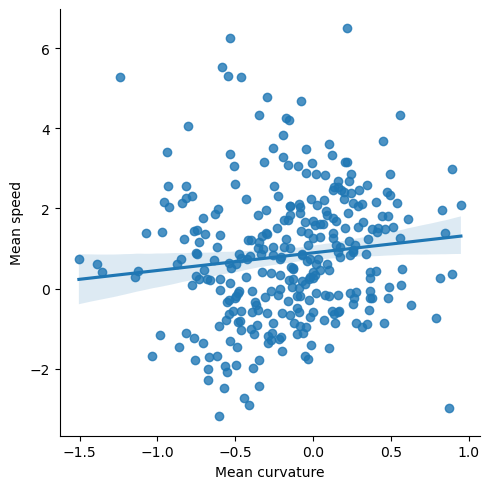

In [106]:
from basicUtils import nonan_pairs,plot_bin_means
from scipy import stats
sb.lmplot(delam_stats,x='Mean curvature',y='Mean speed')
X,Y = nonan_pairs(delam_stats['Mean curvature'],delam_stats['Mean speed'])

stats.pearsonr(X,Y)


PearsonRResult(statistic=np.float64(0.0838203687687619), pvalue=np.float64(0.13897857202486455))

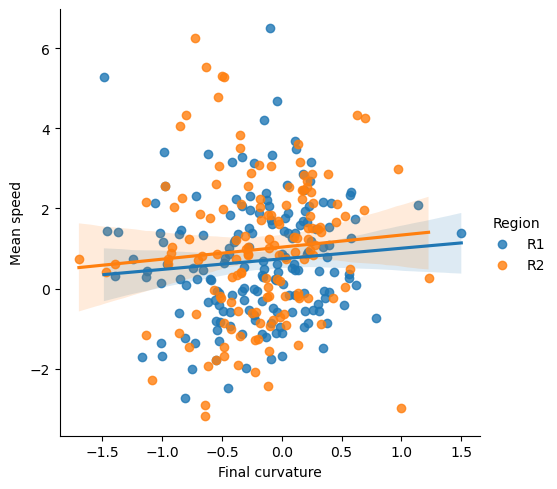

In [95]:
from basicUtils import nonan_pairs
sb.lmplot(delam_stats,x='Final curvature',y='Mean speed',hue='Region')
X,Y = nonan_pairs(delam_stats['Final curvature'],delam_stats['Mean speed'])

stats.pearsonr(X,Y)


(np.float64(-2.9846163269575814), np.float64(0.0030644890797586425))


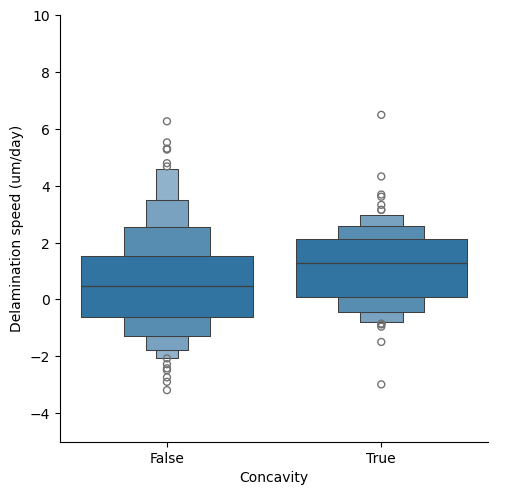

In [96]:
from basicUtils import ttest_from_groupby
delam_stats['Concavity'] = delam_stats['Mean curvature'] > 0
sb.catplot(delam_stats,x='Concavity',y='Mean speed',kind='boxen')

print(ttest_from_groupby(delam_stats,field2group='Concavity',field2test='Mean speed'))
plt.ylabel('Delamination speed (um/day)')
plt.ylim([-5,10])

plt.savefig(path.join('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Delamination analysis/delamination_speed_v_curvature.eps'))

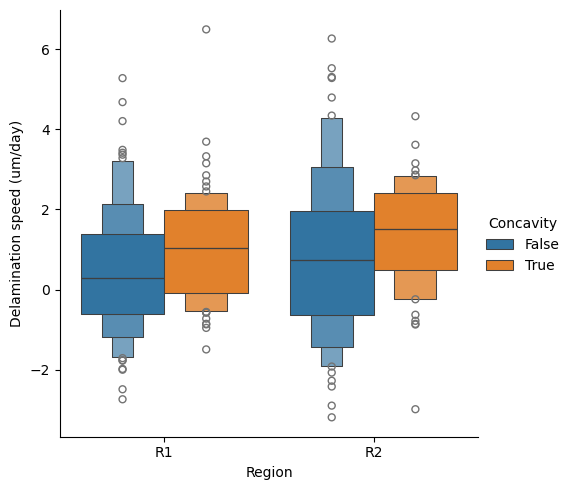

In [97]:
from basicUtils import ttest_from_groupby
delam_stats['Concavity'] = delam_stats['Mean curvature'] > 0
sb.catplot(delam_stats,hue='Concavity',y='Mean speed',kind='boxen',x='Region')

ttest_from_groupby(delam_stats,field2group='Concavity',field2test='Mean speed')
plt.ylabel('Delamination speed (um/day)')

plt.savefig(path.join('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Delamination analysis/delamination_speed_v_curvature_by_region.eps'))

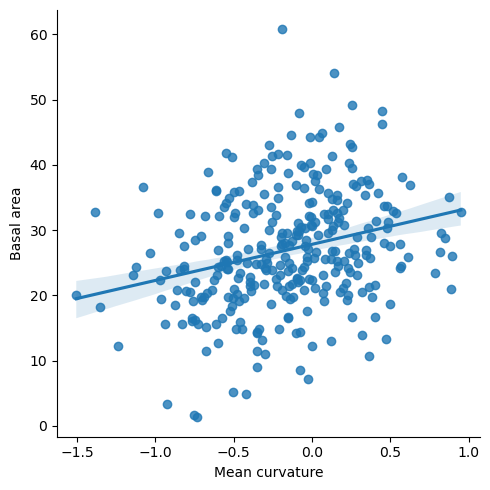

In [107]:
sb.lmplot(delam_stats,x='Mean curvature',y='Basal area')

In [104]:
delam_stats['Basal area rate'].mean()

np.float64(-2.1106230031948883)